In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


In [3]:
# Normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [ ]:
CANVAS = 96 # image is 96x96
OBJ = 32    # object inside image is 32x32 => size of region proposal

In [ ]:
NUM_CLASSES = 10

VOC_LABELS = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

In [ ]:
def create_sample(cifar_img, label, canvas_size=96, obj_size=32):
    # Create Blank canvas
    canvas = np.zeros((canvas_size, canvas_size, 3), dtype=np.float32)
    # Random index for placing the object
    max_x = canvas_size - obj_size
    max_y = canvas_size - obj_size
    x1 = np.random.randint(0, max_x + 1)
    y1 = np.random.randint(0, max_y + 1)
    x2 = x1 + obj_size
    y2 = y1 + obj_size
    # Place image
    canvas[y1:y2, x1:x2, :] = cifar_img
    # Normalized bounding box (to size of canvas)
    bbox = np.array([
        x1 / canvas_size,
        y1 / canvas_size,
        x2 / canvas_size,
        y2 / canvas_size
    ], dtype=np.float32)

    return canvas, label, bbox

In [ ]:
def build_dataset(x_data, y_data, num_samples):
    images = []
    labels = []
    bboxes = []
    # Randomly sample from the dataset and create new samples
    for i in range(num_samples):
        idx = np.random.randint(0, len(x_data))
        img = x_data[idx]
        label = int(y_data[idx][0])
        # Create new sample with random placement
        canvas_img, class_label, bbox = create_sample(img, label)
        # Append to lists
        images.append(canvas_img)
        labels.append(class_label)
        bboxes.append(bbox)

    return np.array(images), np.array(labels), np.array(bboxes)

In [ ]:
# Build new datasets with random placements
x_train_loc, y_train_cls, y_train_bbox = build_dataset(x_train, y_train, 8000)
x_test_loc,  y_test_cls,  y_test_bbox  = build_dataset(x_test,  y_test,  2000)

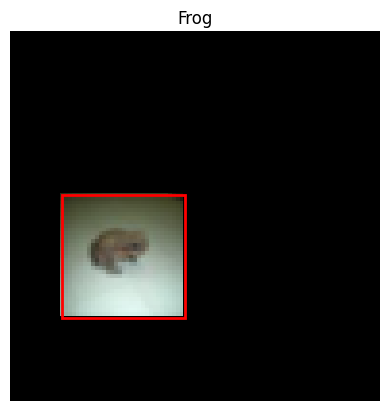

In [17]:
def visualize_sample(img, label, bbox):
    h, w, _ = img.shape

    x1 = int(bbox[0] * w)
    y1 = int(bbox[1] * h)
    x2 = int(bbox[2] * w)
    y2 = int(bbox[3] * h)

    plt.imshow(img)
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2)
    )
    plt.title(VOC_LABELS[label])
    plt.axis('off')
    plt.show()

visualize_sample(x_train_loc[0], y_train_cls[0], y_train_bbox[0])

In [ ]:
from tensorflow.keras import layers, models

input_img = layers.Input(shape=(96, 96, 3))

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)

cls_output = layers.Dense(10, activation='softmax', name='class_output')(x)

bbox_output = layers.Dense(4, activation='sigmoid', name='bbox_output')(x)

model = models.Model(
    inputs=input_img, outputs=[cls_output, bbox_output]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 24,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 24,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 12, 12,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 18432)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  4,718,848 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 10)        │      2,570 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │      1,028 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,815,694 (18.37 MB)

 Trainable params: 4,815,694 (18.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss={
        'class_output': tf.keras.losses.SparseCategoricalCrossentropy(),
        'bbox_output': tf.keras.losses.MeanSquaredError()
    },
    metrics={
        'class_output': 'accuracy',
        'bbox_output': 'mse'
    }
)

In [33]:
history = model.fit(
    x_train_loc,
    {
        'class_output': y_train_cls,
        'bbox_output': y_train_bbox
    },
    validation_data=(
        x_test_loc,
        {
            'class_output': y_test_cls,
            'bbox_output': y_test_bbox
        }
    ),
    epochs=8,
    batch_size=32
)

Epoch 1/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - bbox_output_loss: 2.0306e-04 - bbox_output_mse: 2.0306e-04 - class_output_accuracy: 1.0000 - class_output_loss: 1.4273e-05 - loss: 2.1734e-04 - val_bbox_output_loss: 6.6331e-04 - val_bbox_output_mse: 6.6317e-04 - val_class_output_accuracy: 0.3195 - val_class_output_loss: 7.0723 - val_loss: 7.0805
Epoch 2/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - bbox_output_loss: 1.7587e-04 - bbox_output_mse: 1.7587e-04 - class_output_accuracy: 1.0000 - class_output_loss: 1.3513e-05 - loss: 1.8938e-04 - val_bbox_output_loss: 6.3028e-04 - val_bbox_output_mse: 6.2803e-04 - val_class_output_accuracy: 0.3235 - val_class_output_loss: 7.0559 - val_loss: 7.0643
Epoch 3/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - bbox_output_loss: 1.3979e-04 - bbox_output_mse: 1.3979e-04 - class_output_accuracy: 1.0000 - class_output_loss: 1.1060e-05 - loss: 1.5085e-04 - val_bbox_output_loss: 6.2091e-04 - val_bbox_output_mse: 6.2054e-04 - val_class_output_accuracy: 0.

In [44]:
pred_cls, pred_bbox = model.predict(x_test_loc[:1])

print("Predicted class:", pred_cls.argmax())
print("True class:", y_test_cls[0])

print("Predicted bbox:", pred_bbox[0])
print("True bbox:", y_test_bbox[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted class: 3
True class: 2
Predicted bbox: [0.57137775 0.40506047 0.89065564 0.73267555]
True bbox: [0.5416667  0.42708334 0.875      0.7604167 ]


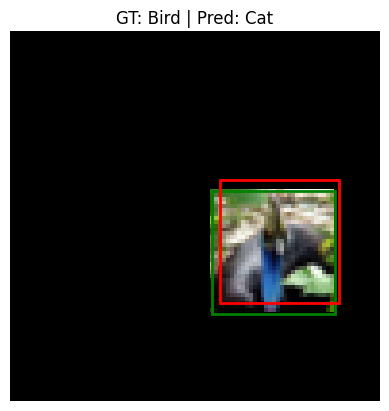

In [45]:
import matplotlib.pyplot as plt
import numpy as np

img = x_test_loc[0]
true_bbox = y_test_bbox[0]
pred_bbox = pred_bbox[0]
true_label = y_test_cls[0]
pred_label = pred_cls.argmax()

h, w, _ = img.shape

# Convert normalized bbox to pixels
def denorm(b):
    x1 = int(b[0] * w)
    y1 = int(b[1] * h)
    x2 = int(b[2] * w)
    y2 = int(b[3] * h)
    return x1, y1, x2, y2

tx1, ty1, tx2, ty2 = denorm(true_bbox)
px1, py1, px2, py2 = denorm(pred_bbox)

plt.imshow(img)
plt.gca().add_patch(plt.Rectangle((tx1, ty1), tx2-tx1, ty2-ty1,
                                  fill=False, edgecolor='green', linewidth=2))
plt.gca().add_patch(plt.Rectangle((px1, py1), px2-px1, py2-py1,
                                  fill=False, edgecolor='red', linewidth=2))

plt.title(f"GT: {VOC_LABELS[true_label]} | Pred: {VOC_LABELS[pred_label]}")
plt.axis('off')
plt.show()

In [39]:
def compute_iou(box1, box2):
    """
    box format: [x1, y1, x2, y2] normalized between 0 and 1
    """

    # 1️⃣ Intersection rectangle
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    # 2️⃣ Intersection area
    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    # 3️⃣ Union area
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - inter_area

    # 4️⃣ IoU
    iou = inter_area / union_area if union_area > 0 else 0.0
    return iou

In [40]:
def evaluate_mean_iou(model, x_test, y_test_bbox, num_samples=200):
    idxs = np.random.choice(len(x_test), num_samples, replace=False)

    ious = []

    for idx in idxs:
        img = x_test[idx:idx+1]
        _, pred_bbox = model.predict(img, verbose=0)

        pred_box = pred_bbox[0]
        true_box = y_test_bbox[idx]

        iou = compute_iou(pred_box, true_box)
        ious.append(iou)

    mean_iou = np.mean(ious)
    return mean_iou


mean_iou = evaluate_mean_iou(model, x_test_loc, y_test_bbox, num_samples=200)
print("Mean IoU over 200 samples:", mean_iou)

Mean IoU over 200 samples: 0.8182057


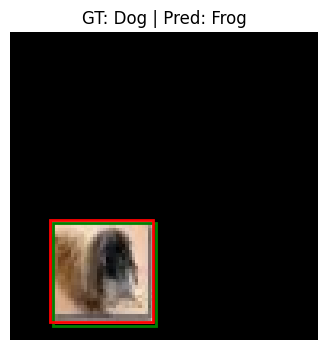

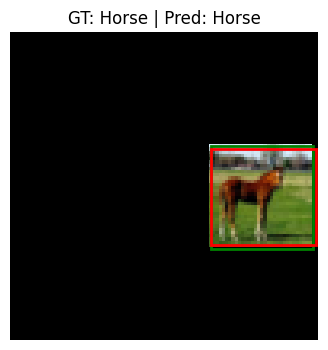

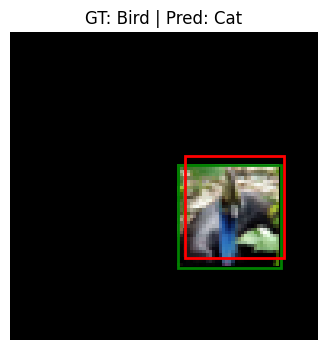

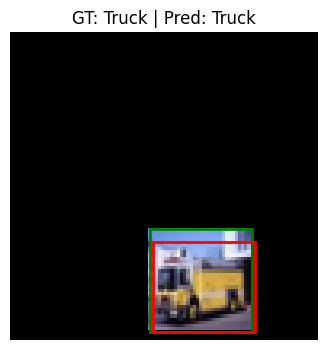

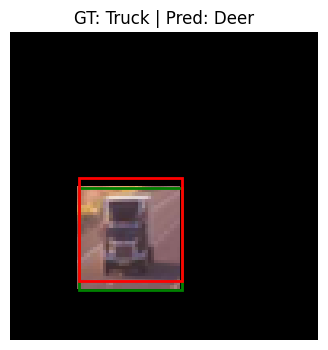

In [41]:
import random
import matplotlib.pyplot as plt

def visualize_predictions(model, x_test, y_test_cls, y_test_bbox, num_samples=5):
    for _ in range(num_samples):
        idx = random.randint(0, len(x_test) - 1)
        img = x_test[idx:idx+1]

        pred_cls, pred_bbox = model.predict(img, verbose=0)

        pred_label = pred_cls[0].argmax()
        true_label = y_test_cls[idx]

        pred_box = pred_bbox[0]
        true_box = y_test_bbox[idx]

        h, w, _ = x_test[0].shape

        def denorm(b):
            x1 = int(b[0] * w)
            y1 = int(b[1] * h)
            x2 = int(b[2] * w)
            y2 = int(b[3] * h)
            return x1, y1, x2, y2

        tx1, ty1, tx2, ty2 = denorm(true_box)
        px1, py1, px2, py2 = denorm(pred_box)

        plt.figure(figsize=(4,4))
        plt.imshow(x_test[idx])
        plt.gca().add_patch(plt.Rectangle((tx1, ty1), tx2-tx1, ty2-ty1,
                                          fill=False, edgecolor='green', linewidth=2))
        plt.gca().add_patch(plt.Rectangle((px1, py1), px2-px1, py2-py1,
                                          fill=False, edgecolor='red', linewidth=2))

        plt.title(f"GT: {VOC_LABELS[true_label]} | Pred: {VOC_LABELS[pred_label]}")
        plt.axis('off')
        plt.show()

visualize_predictions(model, x_test_loc, y_test_cls, y_test_bbox, num_samples=5)

### Why is bounding box prediction a regression problem?

Bounding boxes are defined by continuous coordinates (x1, y1, x2, y2). Predicting these values requires estimating real-valued numbers, not discrete classes. Therefore, it is naturally treated as a regression problem, unlike classification where outputs are categorical labels.

### Why are bounding boxes normalized?

Bounding boxes are normalized between 0 and 1 relative to the canvas size to:

Make the model resolution-independent. The same model can handle images of different sizes without retraining.

Keep predictions in a standard scale, simplifying training and avoiding numerical instability.

Ensure the sigmoid activation on the bounding box head outputs valid coordinates.

### What happens if the bounding box head does not use sigmoid activation?

Without a sigmoid:

Predicted values are unbounded → could be negative or exceed 1.

Normalized coordinates may fall outside the image, producing invalid bounding boxes.

Training may become unstable since the model could generate impossible coordinates.

Using sigmoid ensures all predicted coordinates stay in [0,1], matching the normalized ground truth.

###  Why is IoU more meaningful than MSE for localization evaluation?

MSE measures coordinate-wise error, but it does not account for the overlap between predicted and ground-truth boxes.

IoU directly measures how well the predicted box covers the true object.

A model could have low MSE but poor overlap if the box is shifted slightly; IoU captures this better.

Therefore, IoU is a task-relevant metric for object detection.

### How would this approach change if multiple objects were present in each image?

The current pipeline assumes one object per image; the model predicts one class and one bounding box.

For multiple objects:

The model would need to output multiple bounding boxes and class predictions (e.g., using anchors or a detection framework like YOLO or Faster R-CNN).

Loss functions would handle matching predicted boxes to ground truth boxes.

The dataset construction would include all objects in the canvas, not just one.

This requires a more complex architecture and post-processing (e.g., non-max suppression) to handle overlapping predictions.